# Exploratory Data Analysis — Cardiotocographic Dataset

**Objective:** Conduct a thorough exploratory analysis of the `Cardiotocographic.csv` dataset to uncover insights, identify patterns, and understand the dataset's underlying structure, using statistical summaries, visualizations, and data manipulation techniques.

**About the data:** Each row is a Cardiotocogram (CTG) reading — a fetal monitoring record. Key columns:

| Column | Likely Meaning |
|---|---|
| `LB` | Baseline Fetal Heart Rate (FHR) |
| `AC` | Accelerations in FHR (sign of fetal well-being) |
| `FM` | Fetal Movements detected |
| `UC` | Uterine Contractions |
| `DL` | Decelerations, Late (can signal fetal distress) |
| `DS` | Decelerations, Short |
| `DP` | Decelerations, Prolonged |
| `ASTV` | % of time with Abnormal Short Term Variability |
| `MSTV` | Mean Short Term Variability |
| `ALTV` | % of time with Abnormal Long Term Variability |
| `MLTV` | Mean Long Term Variability |

The dataset also includes `Width` (histogram width of the FHR signal), `Tendency` (histogram tendency: left-asymmetric / symmetric / right-asymmetric), and `NSP` — the **target label**: fetal state classified as **1 = Normal, 2 = Suspect, 3 = Pathologic**.

**Notebook structure:**
1. Data Cleaning and Preparation
2. Statistical Summary
3. Data Visualization
4. Pattern Recognition and Insights
5. Conclusion

## Setup

Import the libraries used throughout the analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# 1. Data Cleaning and Preparation

## 1.1 Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Cardiotocographic.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 2126 rows x 14 columns


           LB        AC   FM        UC  ...  MLTV  Width  Tendency  NSP
0  120.000000  0.000000  0.0  0.000000  ...   2.4   64.0  0.999926  2.0
1  132.000000  0.006380  0.0  0.006380  ...  10.4  130.0  0.000000  1.0
2  133.000000  0.003322  0.0  0.008306  ...  13.4  130.0  0.000000  1.0
3  134.000000  0.002561  0.0  0.007742  ...  23.0  117.0  1.000000  1.0
4  131.948232  0.006515  0.0  0.008143  ...  19.9  117.0  1.000000  1.0

[5 rows x 14 columns]

In [3]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


**Data type check:** every column is already numeric (`float64`) — there are no numbers stored as text/strings that need converting, so no dtype-inconsistency fix is needed there. However, `.info()` shows several columns with fewer non-null entries than the total row count, so there are missing values to handle.

## 1.2 Handle Missing Values

In [4]:
# Count missing values per column
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# How much of EACH affected row is actually missing?
row_missing_pct = df.isna().mean(axis=1) * 100
print("\nRows with any missing value, and what % of that row's fields are missing:")
print(row_missing_pct[row_missing_pct > 0].describe())

Missing values per column:
LB          21
AC          20
DS          21
DP          21
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Rows with any missing value, and what % of that row's fields are missing:
count    21.000000
mean     56.802721
std       1.558699
min      50.000000
25%      57.142857
50%      57.142857
75%      57.142857
max      57.142857
dtype: float64


**Finding:** the missing values aren't scattered randomly — the same **21 rows** are each missing roughly **50–57% of their fields** (8 of 14 columns), while every other row is fully complete. Imputing that much of a single row would mean mostly fabricating it, so **deletion is the more appropriate strategy here** rather than imputation. We drop these 21 incomplete rows.

In [5]:
# Drop rows that have any missing values (confirmed above to be the same 21 heavily-incomplete rows)
before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)

print(f"Rows before: {before}, rows after dropping incomplete rows: {after} (removed {before - after})")
print(f"Remaining missing values: {df.isna().sum().sum()}")

Rows before: 2126, rows after dropping incomplete rows: 2105 (removed 21)
Remaining missing values: 0


## 1.3 Remove Duplicate Records

In [6]:
# Check for and remove fully duplicated rows
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 2
Shape after removing duplicates: (2103, 14)


## 1.4 Fix Inconsistent Categorical Encodings (`Tendency`, `NSP`)

`Tendency` should only take the values **{-1, 0, 1}** (left-asymmetric / symmetric / right-asymmetric), and `NSP` should only take **{1, 2, 3}** (Normal / Suspect / Pathologic). Let's check whether that's actually true in the data.

In [7]:
# Inspect the actual range of these two columns, which should be small fixed sets of integers
print("Tendency -> min:", df["Tendency"].min(), " max:", df["Tendency"].max())
print("NSP      -> min:", df["NSP"].min(), " max:", df["NSP"].max())

print("\nTendency values that are NOT in {-1, 0, 1}:", (~df["Tendency"].round().isin([-1, 0, 1])).sum())
print("NSP values that are NOT in {1, 2, 3}:", (~df["NSP"].round().isin([1, 2, 3])).sum())

Tendency -> min: -3.0  max: 3.0
NSP      -> min: -1.025988003  max: 5.0

Tendency values that are NOT in {-1, 0, 1}: 10
NSP values that are NOT in {1, 2, 3}: 10


**Finding:** both columns are supposed to be small integer category codes, but instead contain continuous, noisy values — including some clearly invalid codes (`Tendency` near -3 or 3; `NSP` near -1 or 5), which fall outside the valid category ranges entirely. This is a data-type/encoding inconsistency: these are categorical variables that have picked up spurious continuous noise and out-of-range codes, most likely from a data-entry or export error.

**Fix:** round each value to the nearest whole number, then clip to the valid category range, and cast to integer.

In [8]:
# Round to the nearest integer, then clip to the valid category range for each column
df["Tendency"] = df["Tendency"].round().clip(-1, 1).astype(int)
df["NSP"] = df["NSP"].round().clip(1, 3).astype(int)

print("Tendency value counts after cleaning:")
print(df["Tendency"].value_counts().sort_index())
print("\nNSP value counts after cleaning:")
print(df["NSP"].value_counts().sort_index())

Tendency value counts after cleaning:
Tendency
-1     169
 0    1095
 1     839
Name: count, dtype: int64

NSP value counts after cleaning:
NSP
1    1634
2     293
3     176
Name: count, dtype: int64


In [9]:
# Map NSP's numeric codes to readable labels for use in visualizations later
nsp_labels = {1: "Normal", 2: "Suspect", 3: "Pathologic"}
df["NSP_Label"] = df["NSP"].map(nsp_labels)
df["NSP_Label"].value_counts()

NSP_Label
Normal        1634
Suspect        293
Pathologic     176
Name: count, dtype: int64

## 1.5 Detect and Treat Outliers

**Step 1 — domain-knowledge check.** Several columns are physically counts, rates, durations, or percentages, so they **cannot legitimately be negative**, and `ASTV`/`ALTV` are percentages so they **cannot exceed 100**. Let's check.

In [10]:
# Columns that represent counts/rates/durations and therefore cannot be negative
nonneg_cols = ["LB", "AC", "FM", "UC", "DL", "DS", "DP", "ASTV", "MSTV", "ALTV", "MLTV", "Width"]

negative_counts = (df[nonneg_cols] < 0).sum()
print("Number of impossible negative values per column:")
print(negative_counts[negative_counts > 0])

print("\nASTV values above 100 (impossible for a percentage):", (df["ASTV"] > 100).sum())
print("ALTV values above 100 (impossible for a percentage):", (df["ALTV"] > 100).sum())

Number of impossible negative values per column:
AC       29
FM       52
UC       13
DL       36
DS       53
DP       52
ASTV      5
MSTV      3
ALTV     37
MLTV     11
Width     5
dtype: int64

ASTV values above 100 (impossible for a percentage): 5
ALTV values above 100 (impossible for a percentage): 7


**Finding:** many columns contain physically impossible values — negative accelerations, movements, contractions, decelerations, and variability measures, plus `ASTV`/`ALTV` percentages that exceed 100%. These are clear data errors rather than genuine clinical extremes, so we correct them using domain knowledge: clip negative values to 0, and clip `ASTV`/`ALTV` to a 100 ceiling.

In [11]:
# Fix impossible negative values in count/rate/duration columns
for col in nonneg_cols:
    df[col] = df[col].clip(lower=0)

# Fix impossible percentages
df["ASTV"] = df["ASTV"].clip(upper=100)
df["ALTV"] = df["ALTV"].clip(upper=100)

print("Remaining negative values:", (df[nonneg_cols] < 0).sum().sum())
print("Remaining ASTV/ALTV values above 100:",
      ((df['ASTV'] > 100) | (df['ALTV'] > 100)).sum())

Remaining negative values: 0
Remaining ASTV/ALTV values above 100: 0


**Step 2 — statistical outlier check (IQR method).** After fixing the impossible-by-definition values above, we use the interquartile range (IQR) method to see how many *statistically* extreme values remain in each continuous numeric column. Values beyond 1.5×IQR from Q1/Q3 are flagged.

In [12]:
# Continuous numeric columns to check (categorical Tendency/NSP are excluded)
continuous_cols = ["LB", "AC", "FM", "UC", "DL", "DS", "DP", "ASTV", "MSTV", "ALTV", "MLTV", "Width"]

outlier_report = []
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({"Column": col, "Lower Bound": round(lower, 2),
                            "Upper Bound": round(upper, 2), "Outlier Count": n_outliers})

outlier_df = pd.DataFrame(outlier_report)
outlier_df

   Column  Lower Bound  Upper Bound  Outlier Count
0      LB       105.00       161.00             10
1      AC        -0.01         0.01             35
2      FM        -0.00         0.01            336
3      UC        -0.01         0.01              9
4      DL        -0.00         0.01            118
5      DS         0.00         0.00             67
6      DP         0.00         0.00            232
7    ASTV       -11.50       104.50              0
8    MSTV        -0.80         3.20             75
9    ALTV       -16.50        27.50            314
10   MLTV        -4.85        20.35             76
11  Width       -57.50       194.50              5

**Treatment decision:** rather than deleting these rows (which would discard real patient readings — some clinical extremes like a genuinely high `LB` or high `ASTV` are exactly the kind of case this monitoring exists to catch), we **cap (winsorize)** each value to its IQR bound. This tames the influence of extreme values on means/plots while preserving every patient record and not fabricating any data.

**One exception:** for `DS` and `DP`, the table above shows an IQR bound of **[0.00, 0.00]** — meaning at least 75% of readings are exactly 0. Winsorizing with a zero-width bound would clip *every* nonzero reading down to 0, wiping out the column's real signal rather than just its extremes. So we skip winsorizing for any column whose IQR is 0, and only winsorize columns where the bound is actually a meaningful range.

In [13]:
# Winsorize: cap remaining statistical outliers at their IQR bounds, column by column,
# but SKIP any column whose IQR is 0 (winsorizing there would erase real data, not just outliers)
skipped_cols = []
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        skipped_cols.append(col)
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)

print(f"Skipped winsorizing for zero-IQR column(s): {skipped_cols}")
print("Data cleaning complete.")
print(f"Final shape: {df.shape}")
df.head()

Skipped winsorizing for zero-IQR column(s): ['DS', 'DP']
Data cleaning complete.
Final shape: (2103, 15)


           LB        AC   FM        UC  ...  Width  Tendency  NSP  NSP_Label
0  120.000000  0.000000  0.0  0.000000  ...   64.0         1    2    Suspect
1  132.000000  0.006380  0.0  0.006380  ...  130.0         0    1     Normal
2  133.000000  0.003322  0.0  0.008306  ...  130.0         0    1     Normal
3  134.000000  0.002561  0.0  0.007742  ...  117.0         1    1     Normal
4  131.948232  0.006515  0.0  0.008143  ...  117.0         1    1     Normal

[5 rows x 15 columns]

# 2. Statistical Summary

In [14]:
# Central tendency and dispersion for every numeric column
summary = pd.DataFrame({
    "Mean": df[continuous_cols].mean(),
    "Median": df[continuous_cols].median(),
    "Std Dev": df[continuous_cols].std(),
    "IQR": df[continuous_cols].quantile(0.75) - df[continuous_cols].quantile(0.25),
    "Min": df[continuous_cols].min(),
    "Max": df[continuous_cols].max(),
}).round(2)

summary

         Mean  Median  Std Dev    IQR    Min     Max
LB     133.29  133.00     9.98  14.00  105.0  161.00
AC       0.00    0.00     0.00   0.01    0.0    0.01
FM       0.00    0.00     0.00   0.00    0.0    0.01
UC       0.00    0.00     0.00   0.00    0.0    0.01
DL       0.00    0.00     0.00   0.00    0.0    0.01
DS       0.00    0.00     0.00   0.00    0.0    0.00
DP       0.00    0.00     0.00   0.00    0.0    0.01
ASTV    47.02   49.00    17.52  29.00    0.0  100.00
MSTV     1.30    1.20     0.78   1.00    0.0    3.20
ALTV     6.76    0.00    10.36  11.00    0.0   27.50
MLTV     8.03    7.40     5.07   6.30    0.0   20.35
Width   70.49   67.49    39.43  63.00    0.0  194.50

**Interesting findings from the summary:**

- **`LB` (baseline FHR)** averages around 133 bpm with a fairly tight spread (std ~10), consistent with typical fetal heart rate baselines (110–160 bpm).
- **`AC`, `FM`, `DL`, `DS`, `DP`** all have medians at or very near **0**, meaning accelerations, movements, and decelerations are simply **absent in the majority of readings** — they are rare "event" measures rather than variables with a smooth spread.
- **`ASTV`** (mean ~47, up to 100) and **`ALTV`** (mean noticeably lower, with median 0) suggest that abnormal short-term variability is a common, graded phenomenon across recordings, while abnormal long-term variability is more of an occasional/rare event for most patients.
- **`MSTV`** and **`MLTV`** (mean/median short & long term variability) both show std deviations close to or larger than half their mean, indicating high relative variability between patients — consistent with these being sensitive clinical indicators that vary a lot by fetal condition.
- **`Width`** (histogram width of the FHR signal) has one of the largest relative spreads, reflecting how differently "compressed" or "spread out" FHR readings can look between calm and distressed recordings.

In [15]:
# Distribution of the target label after cleaning
nsp_counts = df["NSP_Label"].value_counts()
nsp_pct = (nsp_counts / len(df) * 100).round(1)

print("NSP (fetal state) distribution:")
for label in nsp_counts.index:
    print(f"  {label}: {nsp_counts[label]} records ({nsp_pct[label]}%)")

NSP (fetal state) distribution:
  Normal: 1634 records (77.7%)
  Suspect: 293 records (13.9%)
  Pathologic: 176 records (8.4%)


**Class imbalance finding:** the large majority of recordings are classified **Normal**, with far fewer **Suspect** and **Pathologic** cases. This is expected clinically (most monitored pregnancies are healthy), but it's an important consideration for any future predictive modeling on this data — a model could reach high accuracy just by always predicting "Normal," so metrics like recall/precision on the minority classes would matter more than overall accuracy.

# 3. Data Visualization

## 3.1 Distributions of Numerical Variables (Histograms)

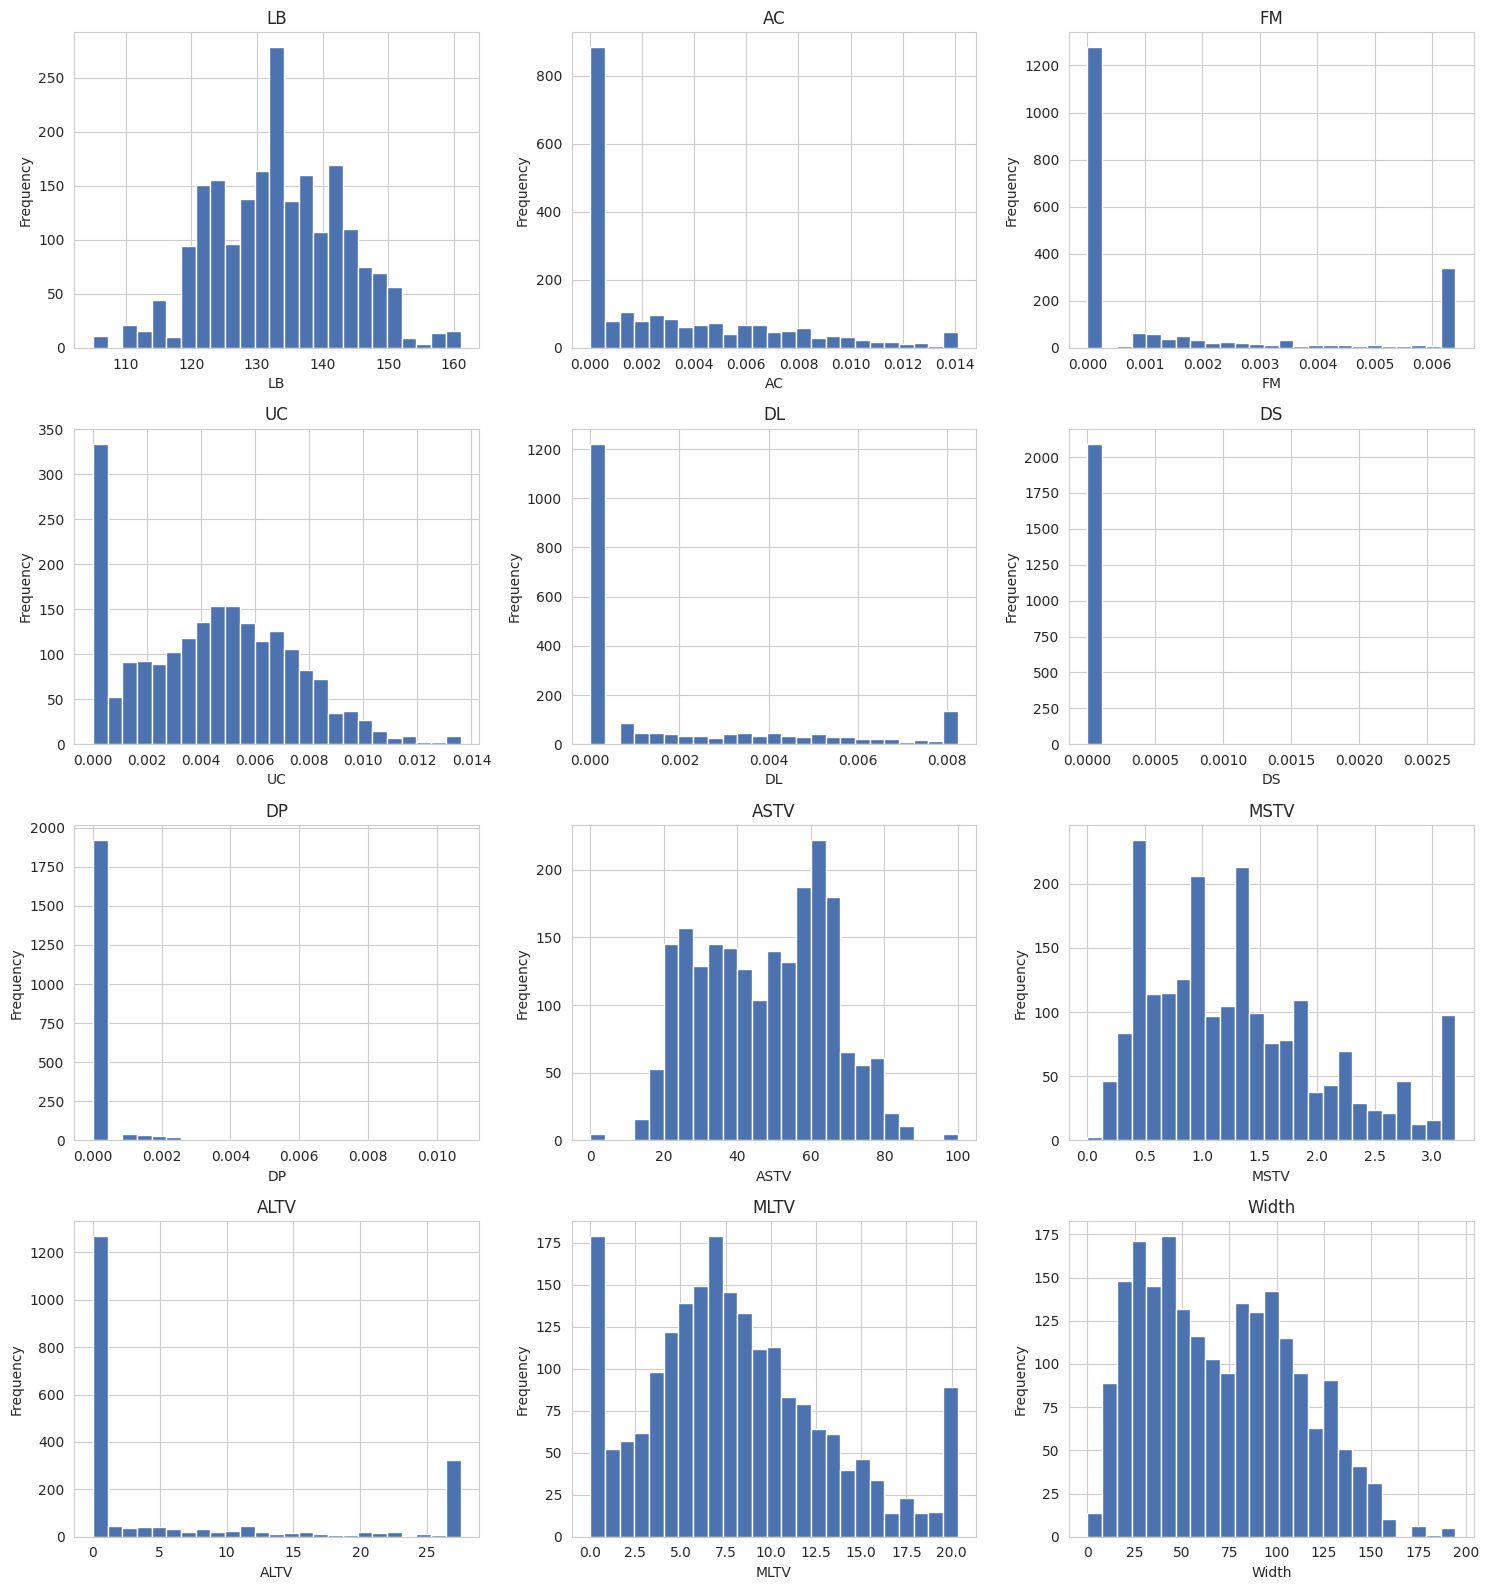

In [16]:
# Histogram grid for all continuous numeric columns
n_cols = 3
n_rows = -(-len(continuous_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col], bins=25, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(continuous_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Reading the histograms:** `AC`, `FM`, `DL`, `DS`, and `DP` are heavily concentrated at (or near) zero with a thin right tail — consistent with them being rare-event measures. `LB` and `MSTV` look closer to a bell shape. `ASTV` is fairly evenly spread across its range, while `ALTV` is dominated by a spike at 0 with a secondary spread of higher values — suggesting two different regimes of long-term variability abnormality across recordings.

## 3.2 Distributions of Numerical Variables (Box Plots)

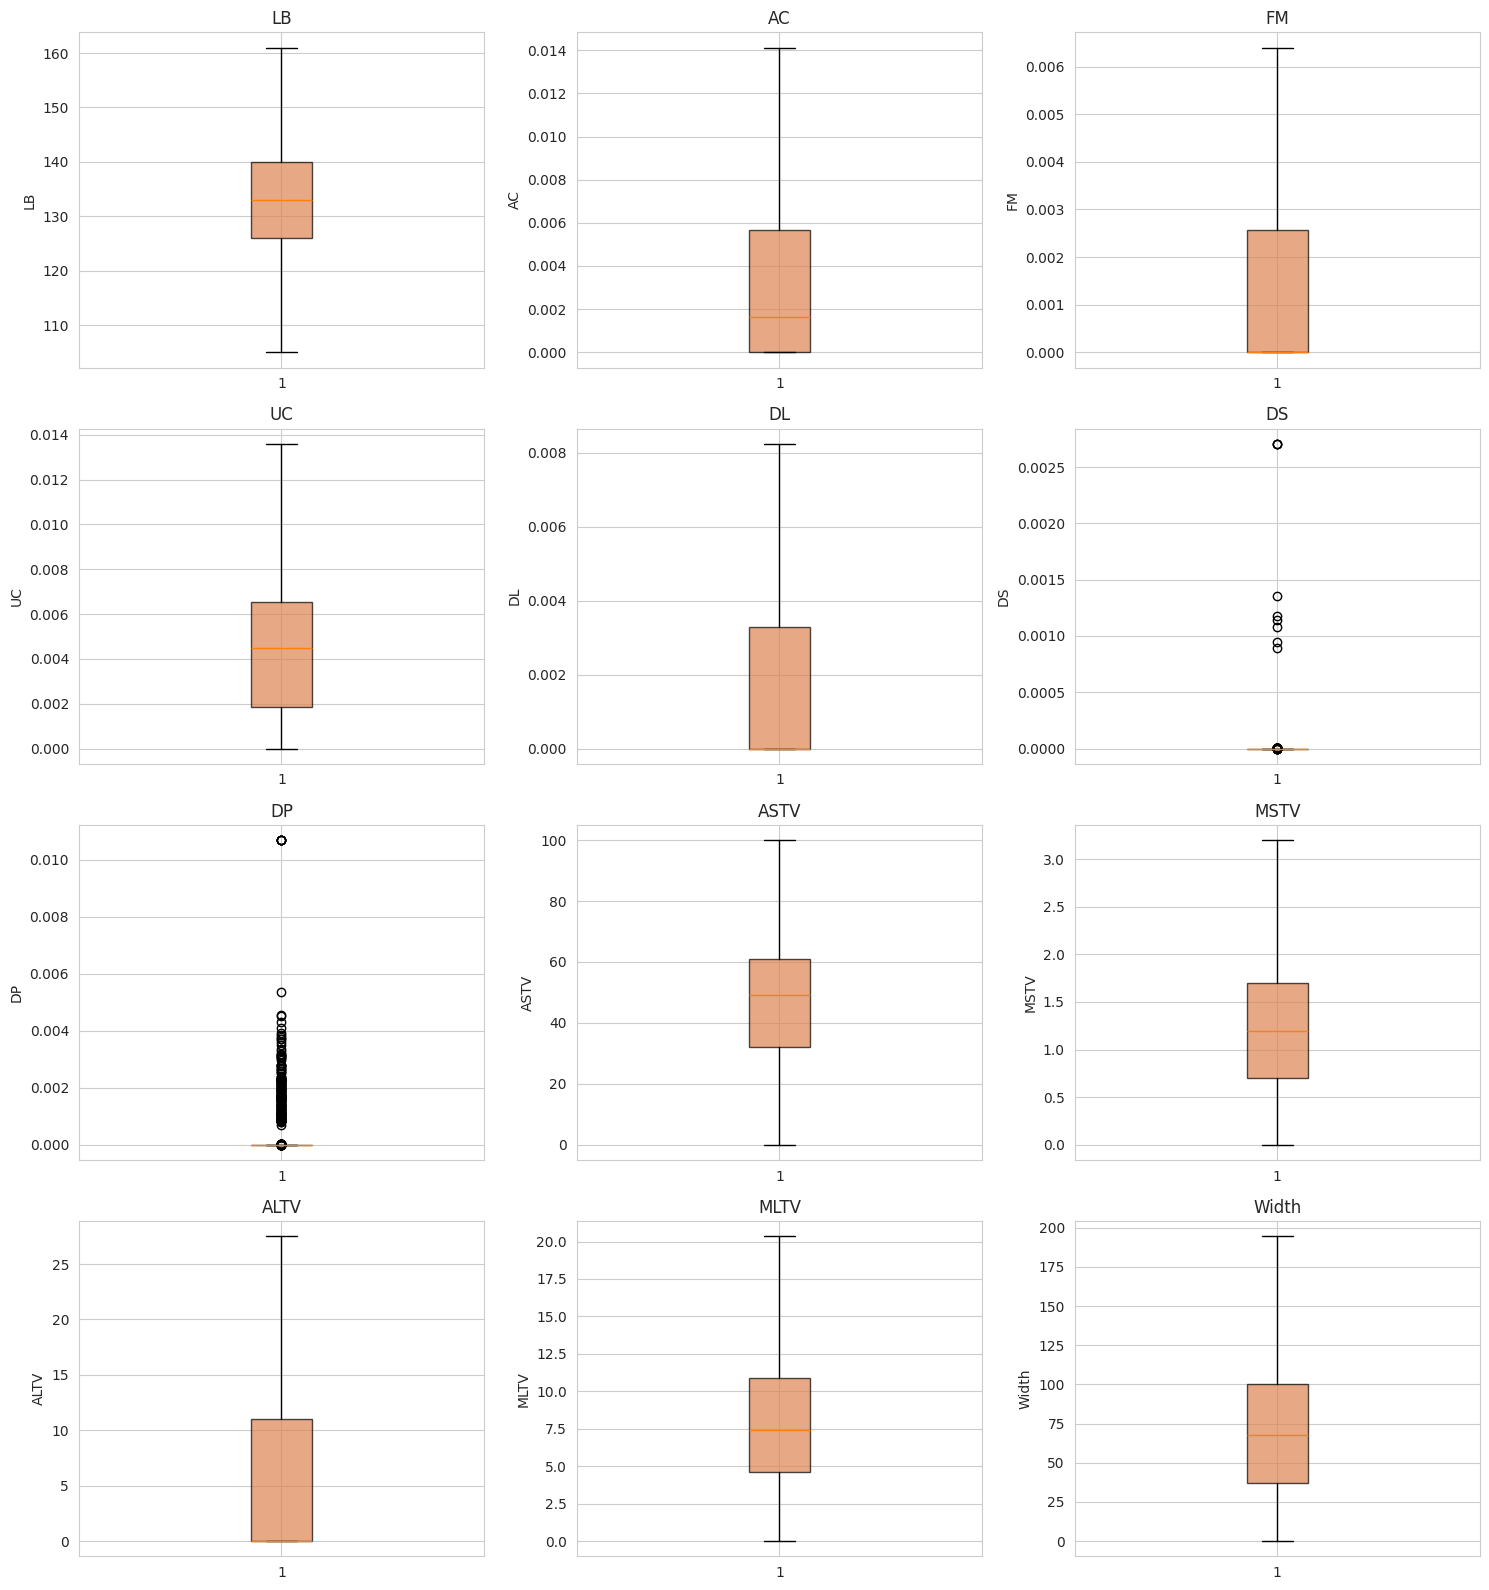

In [17]:
# Boxplot grid for all continuous numeric columns (now winsorized, so extreme tails are capped)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#DD8452", alpha=0.7))
    ax.set_title(col)
    ax.set_ylabel(col)

for ax in axes[len(continuous_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Reading the box plots:** with outliers already winsorized during cleaning, most boxes now sit comfortably within their whiskers. The rare-event columns (`AC`, `FM`, `DL`, `DS`, `DP`) still show their boxes compressed near zero — that's the genuine shape of the data (most readings truly have zero of these events), not a remaining data issue.

## 3.3 Frequency of Categories — `NSP` and `Tendency`

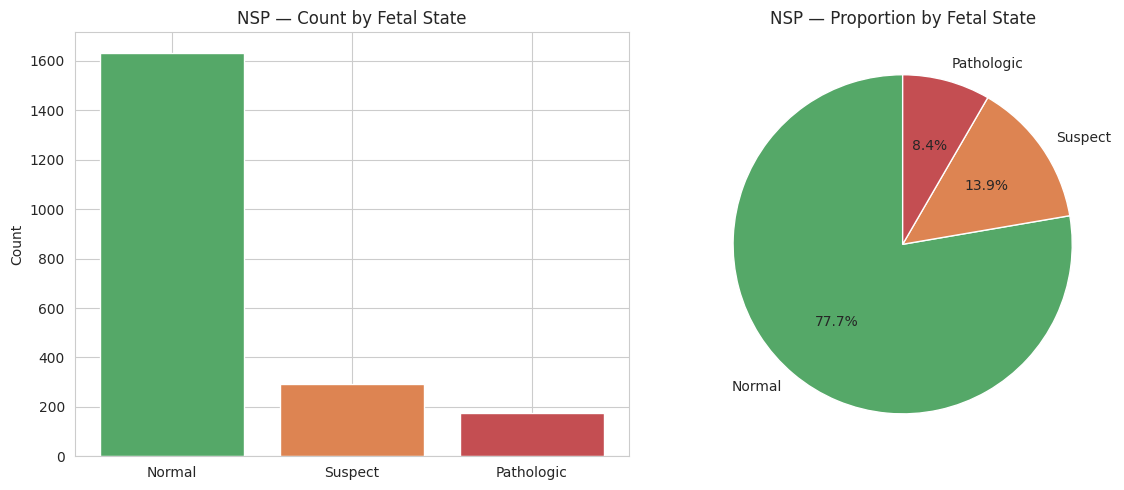

In [18]:
# Bar chart and pie chart for NSP (the categorical fetal-state label)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nsp_order = ["Normal", "Suspect", "Pathologic"]
nsp_counts_ordered = df["NSP_Label"].value_counts().reindex(nsp_order)

axes[0].bar(nsp_counts_ordered.index, nsp_counts_ordered.values,
            color=["#55A868", "#DD8452", "#C44E52"])
axes[0].set_title("NSP — Count by Fetal State")
axes[0].set_ylabel("Count")

axes[1].pie(nsp_counts_ordered.values, labels=nsp_counts_ordered.index, autopct="%1.1f%%",
            colors=["#55A868", "#DD8452", "#C44E52"], startangle=90)
axes[1].set_title("NSP — Proportion by Fetal State")

plt.tight_layout()
plt.show()

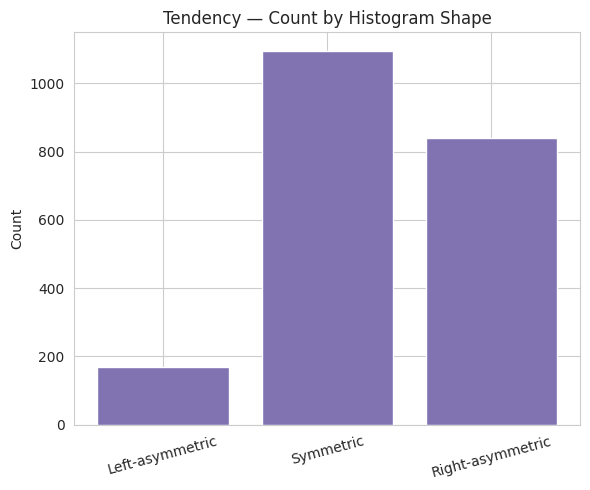

In [19]:
# Bar chart for Tendency (histogram tendency category)
fig, ax = plt.subplots(figsize=(6, 5))
tendency_labels = {-1: "Left-asymmetric", 0: "Symmetric", 1: "Right-asymmetric"}
tendency_counts = df["Tendency"].map(tendency_labels).value_counts().reindex(
    ["Left-asymmetric", "Symmetric", "Right-asymmetric"])

ax.bar(tendency_counts.index, tendency_counts.values, color="#8172B2")
ax.set_title("Tendency — Count by Histogram Shape")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Insight:** most FHR histograms are **symmetric**, with right-asymmetric being the next most common and left-asymmetric the rarest — plausible given that symmetric variability is the "typical" baseline pattern clinicians expect to see most often.

## 3.4 Relationships Between Variables — Correlation Heatmap

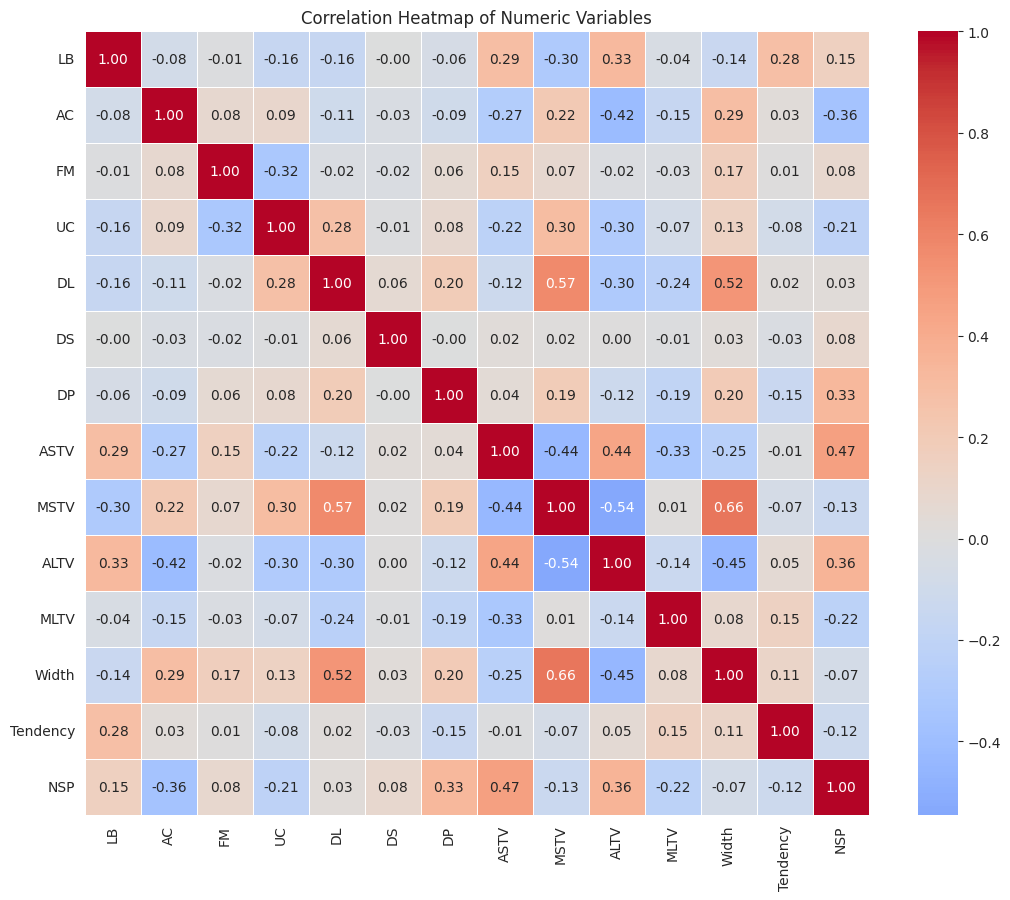

In [20]:
# Correlation heatmap across all numeric columns (including NSP, to see which features relate to fetal state)
corr_cols = continuous_cols + ["Tendency", "NSP"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [21]:
# Pull out the correlations most relevant to the target label, NSP, sorted by strength
nsp_corr = corr_matrix["NSP"].drop("NSP").sort_values(key=abs, ascending=False)
print("Correlation of each variable with NSP (fetal state), strongest first:")
nsp_corr

Correlation of each variable with NSP (fetal state), strongest first:


ASTV        0.467443
AC         -0.358807
ALTV        0.358721
DP          0.330271
MLTV       -0.223992
UC         -0.209821
LB          0.150916
MSTV       -0.128558
Tendency   -0.122346
DS          0.080674
FM          0.077585
Width      -0.069286
DL          0.031676
Name: NSP, dtype: float64

**Correlation insights:**

- **`ASTV`** and **`ALTV`** (abnormal short/long term variability) show the **strongest positive correlations with `NSP`** — i.e., as these abnormality percentages rise, the fetal state tends to shift from Normal toward Suspect/Pathologic. This aligns with clinical intuition: abnormal variability is a warning sign.
- **`MSTV`** correlates **negatively** with `NSP` — higher (healthier) short-term variability is associated with more Normal outcomes, while low variability trends toward Suspect/Pathologic.
- **`AC`** (accelerations) also shows a **negative correlation with `NSP`** — more accelerations (a classic sign of fetal well-being) is associated with more Normal classifications, again matching clinical expectations.
- Several rare-event columns (`DS`, `DP`, `FM`) show weak correlation with `NSP` in this sample, likely because they are zero for the overwhelming majority of records, leaving little variation to correlate with.
- Among the predictors themselves, `ASTV` and `ALTV` are moderately correlated with each other, and `MSTV`/`MLTV` similarly move together — expected, since short-term and long-term variability abnormality measures capture related aspects of the same FHR signal.

## 3.5 Deeper Insights — Violin Plots and Pair Plot

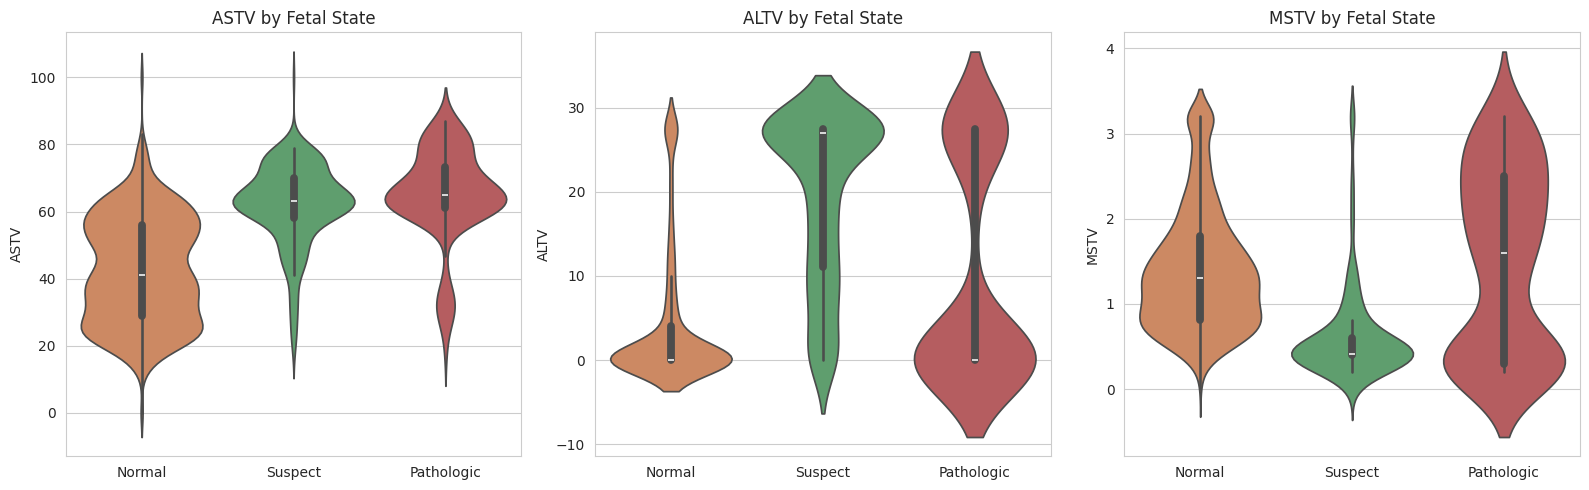

In [22]:
# Violin plots: how do the strongest NSP-correlated variables differ across fetal states?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["ASTV", "ALTV", "MSTV"]):
    sns.violinplot(data=df, x="NSP_Label", y=col, order=nsp_order, ax=ax,
                    hue="NSP_Label", palette=["#55A868", "#DD8452", "#C44E52"], legend=False)
    ax.set_title(f"{col} by Fetal State")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Reading the violin plots:** `ASTV` and `ALTV` both shift visibly higher (and their distributions widen) moving from Normal → Suspect → Pathologic, reinforcing the correlation findings above. `MSTV` shows the opposite pattern — its distribution shifts lower for Pathologic cases — consistent with reduced short-term variability being a marker of fetal compromise.

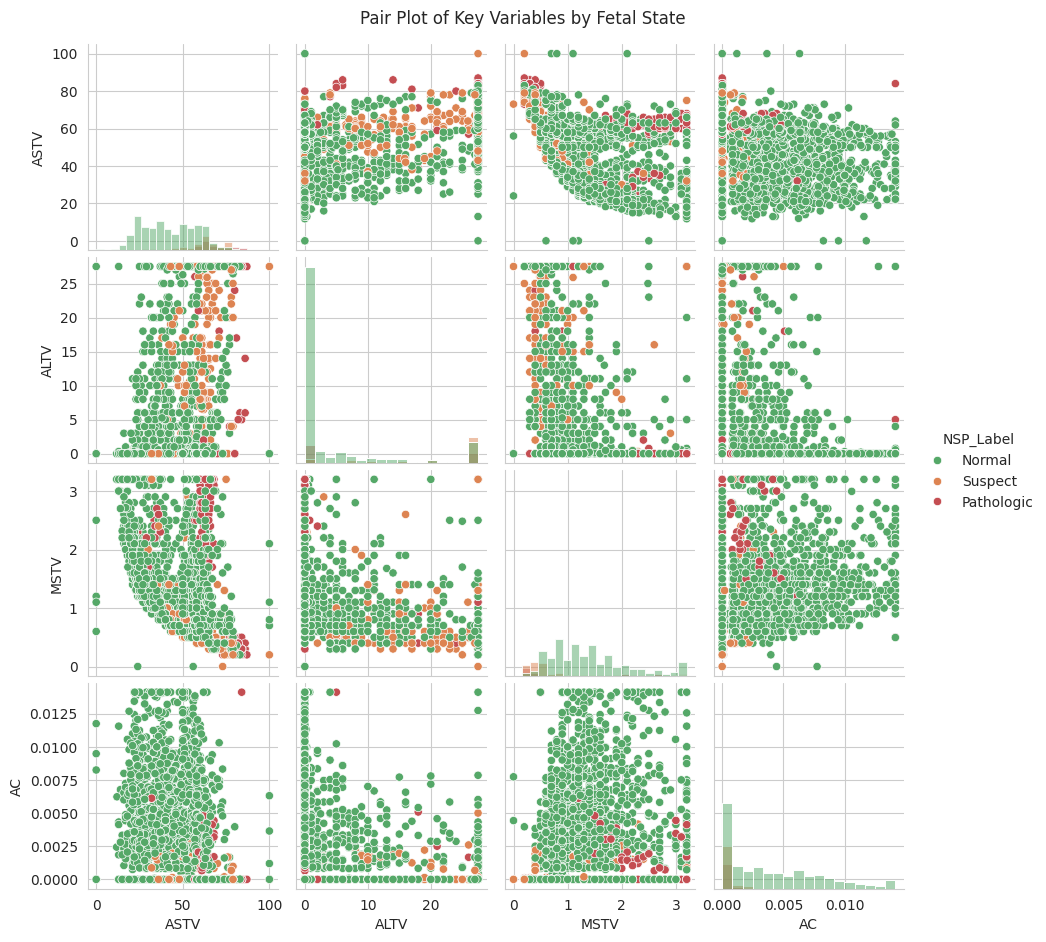

In [23]:
# Pair plot of the variables most strongly associated with NSP, colored by fetal state
pairplot_cols = ["ASTV", "ALTV", "MSTV", "AC", "NSP_Label"]
sns.pairplot(df[pairplot_cols], hue="NSP_Label", hue_order=nsp_order,
             palette=["#55A868", "#DD8452", "#C44E52"], diag_kind="hist", height=2.3)
plt.suptitle("Pair Plot of Key Variables by Fetal State", y=1.02)
plt.show()

**Insight from the pair plot:** Pathologic cases (red) tend to cluster at higher `ASTV`/`ALTV` and lower `AC`/`MSTV` compared to Normal cases (green), which appear more spread out at the "healthier" end of each axis. Suspect cases (orange) generally sit between the two, as expected for an intermediate clinical category — though with meaningful overlap, showing that no single variable cleanly separates all three classes on its own.

# 4. Pattern Recognition and Insights

**Correlations and their potential implications:**
- The strong positive relationship between `ASTV`/`ALTV` and `NSP`, combined with the negative relationship for `MSTV`/`AC`, suggests these four variables together carry much of the useful signal for distinguishing Normal from Suspect/Pathologic recordings — they would be strong candidates as input features for a predictive model of fetal state.
- The moderate correlation between `ASTV` and `ALTV` (and separately between `MSTV` and `MLTV`) suggests some redundancy between short-term and long-term variability measures; a model might not need both pairs to capture most of the same information.

**Temporal patterns:** this dataset does not include a timestamp or sequential ordering column, so no time-series trends could be explored — each row is an independent CTG reading rather than a time series. If sequential/longitudinal data (e.g., multiple readings per patient over time) were available, tracking how `ASTV`/`ALTV`/`MSTV` evolve over a monitoring session could add further diagnostic value.

# 5. Conclusion

**Data cleaning summary:**
- Removed 21 rows that were each missing 50%+ of their fields (deletion was more appropriate than imputation here), plus 2 duplicate rows.
- Corrected `Tendency` and `NSP` from noisy continuous values (with some invalid out-of-range codes) back into their proper small integer category sets.
- Corrected physically impossible negative values and out-of-range percentages across 11 columns using domain knowledge, then used the IQR method to detect and winsorize remaining statistical outliers — preserving every patient record rather than deleting data.

**Key insights from the analysis:**
1. The dataset is **imbalanced** — the large majority of recordings are classified Normal, with far fewer Suspect and Pathologic cases.
2. **`ASTV` and `ALTV`** (abnormal short/long-term variability) are the variables most positively associated with a worse fetal state (`NSP`), while **`MSTV`** and **`AC`** (accelerations) are most negatively associated — i.e., more abnormal variability trends toward Suspect/Pathologic, while more short-term variability and more accelerations trend toward Normal.
3. Several event-type variables (`AC`, `FM`, `DL`, `DS`, `DP`) are zero for the majority of recordings, meaning they behave more like rare-event indicators than smoothly distributed measures.
4. Violin and pair plots confirm visually that Normal, Suspect, and Pathologic cases separate reasonably well along the `ASTV`/`ALTV`/`MSTV`/`AC` axes, though with meaningful overlap between classes — no single variable perfectly separates them.

**Implications for decision-making / further analysis:**
- `ASTV`, `ALTV`, `MSTV`, and `AC` look like strong candidate features for a classification model predicting fetal state (`NSP`), which could serve as a clinical decision-support tool alongside expert review.
- Given the class imbalance, any predictive model built on this data should be evaluated with metrics such as recall/precision on the Suspect and Pathologic classes (not just overall accuracy), since missing a Pathologic case is clinically far more costly than a false alarm.
- Because the rare-event columns are mostly zero, they may contribute little on their own to a model, but could still be useful in combination with other features or as flags for specific rare conditions.
- Future data collection could benefit from tighter validation at the source (e.g., preventing `NSP`/`Tendency` from drifting outside their valid category codes, and preventing negative values in inherently non-negative fields) to reduce the cleaning burden on any downstream analysis.